In [1]:
import pandas as pd
import sqlite3

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

commits = pd.io.sql.read_sql(
    """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
commits.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:45.549397
2,2020-04-17 05:34:24.422370
3,2020-04-17 05:43:27.773992
4,2020-04-17 05:46:32.275104


## Add hour and day type columns

In [3]:
commits['hour'] = commits['timestamp'].dt.hour
commits['dayofweek'] = commits['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
commits['date'] = commits['timestamp'].dt.date
commits['day_type'] = commits['dayofweek'].apply(
    lambda x: 'weekend' if x >= 5 else 'working_day'
)
commits.head()

,timestamp,hour,dayofweek,date,day_type
0,2020-04-17 05:19:02.744528,5,4,2020-04-17,working_day
1,2020-04-17 05:22:45.549397,5,4,2020-04-17,working_day
2,2020-04-17 05:34:24.422370,5,4,2020-04-17,working_day
3,2020-04-17 05:43:27.773992,5,4,2020-04-17,working_day
4,2020-04-17 05:46:32.275104,5,4,2020-04-17,working_day


## Calculate average commits per hour for weekdays and weekends

In [4]:
# Count commits per date+hour+day_type
hourly = commits.groupby(['date', 'hour', 'day_type']).size().reset_index(name='count')

# Average per hour per day_type (only hours that had commits)
avg_hourly = hourly.groupby(['hour', 'day_type'])['count'].mean().unstack()
avg_hourly.head()

day_type,weekend,working_day
hour,,
0,1.0,2.0
1,3.0,NaN
3,1.0,1.0
5,1.0,4.0
6,NaN,1.0


## Plot

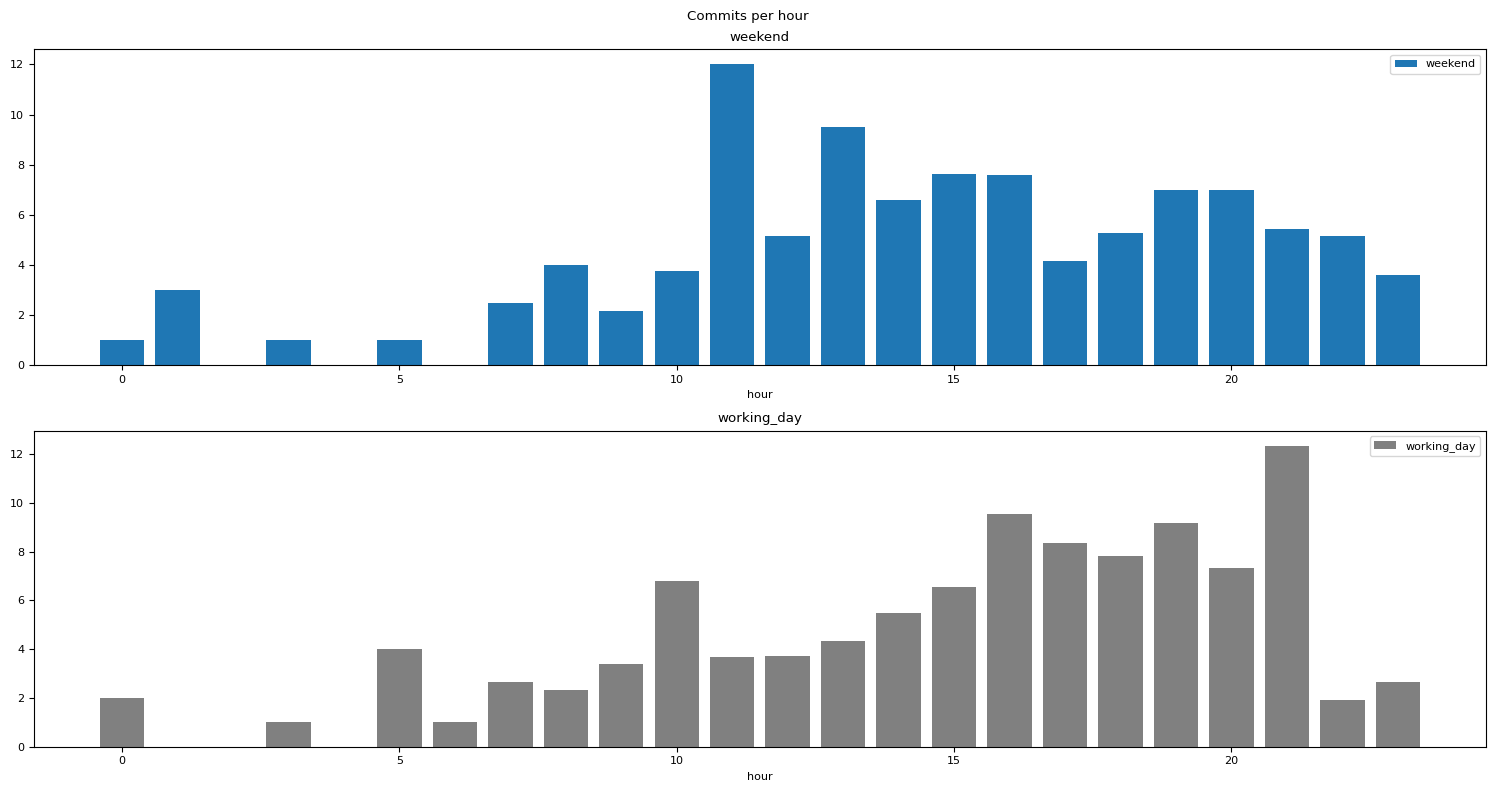

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 8
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

if 'weekend' in avg_hourly.columns:
    axes[0].bar(avg_hourly.index, avg_hourly['weekend'], label='weekend')
    axes[0].set_title('weekend')
    axes[0].set_xlabel('hour')
    axes[0].legend()

if 'working_day' in avg_hourly.columns:
    axes[1].bar(avg_hourly.index, avg_hourly['working_day'], label='working_day', color='gray')
    axes[1].set_title('working_day')
    axes[1].set_xlabel('hour')
    axes[1].legend()

plt.suptitle('Commits per hour')
plt.tight_layout()
plt.show()

## Answer question

In [6]:
if 'working_day' in avg_hourly.columns:
    peak_workday = avg_hourly['working_day'].idxmax()
    print(f'Peak hour on working days: {peak_workday}')

if 'weekend' in avg_hourly.columns:
    peak_weekend = avg_hourly['weekend'].idxmax()
    print(f'Peak hour on weekends: {peak_weekend}')

print(f'\nIs the dynamic different? Working day peak: {peak_workday}h, Weekend peak: {peak_weekend}h')

Peak hour on working days: 21
Peak hour on weekends: 11

Is the dynamic different? Working day peak: 21h, Weekend peak: 11h


Is the dynamic different on working days and weekends? The hour when the number of commits is largest during working days: 21. The hour when it is largest during the weekend: 11.